## Project Overview
The objective of this project is to build a machine learning model to predict loan defaults for Lending Club. This initial Exploratory Data Analysis (EDA) phase focuses on understanding the data's footprint, identifying class imbalances, and handling missing or anomalous data before feature engineering.

### Standard Machine Learning Project Workflow

1. **Business Problem Formulation**: Define the core objective and success metrics (e.g., predict loan defaults to minimize financial risk and maximize approval profit).
2. **Data Collection & Understanding**: Gather raw data and understand the data dictionary.
3. **Exploratory Data Analysis (EDA)**: Visualize data distributions, identify missing values, and uncover relationships between features.
4. **Data Preprocessing & Feature Engineering**: Clean the data, handle outliers, encode categorical variables, and create new predictive features.
5. **Model Selection & Training**: Establish a baseline, select appropriate algorithms, and train the models.
6. **Model Evaluation & Tuning**: Optimize hyperparameters and evaluate using business-appropriate metrics.
7. **Deployment & Monitoring**: Deploy the model to production and monitor for data drift over time.

In [1]:
# Import standard EDA libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore annoying warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Set relative path to the raw data
file_path = '../data/raw/loans.csv'

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display the first 5 rows to ensure it loaded correctly
df.head()

,id,member_id,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,last_pymnt_amnt,loan_status
0,1077501,1296599.0,5000.0,36 months,10.65%,162.87,B,B2,10+ years,RENT,...,27.65,0.0,1.0,3.0,0.0,13648.0,83.7%,9.0,171.62,Fully Paid
1,1077430,1314167.0,2500.0,60 months,15.27%,59.83,C,C4,< 1 year,RENT,...,1.00,0.0,5.0,3.0,0.0,1687.0,9.4%,4.0,119.66,Charged Off
2,1077175,1313524.0,2400.0,36 months,15.96%,84.33,C,C5,10+ years,RENT,...,8.72,0.0,2.0,2.0,0.0,2956.0,98.5%,10.0,649.91,Fully Paid
3,1076863,1277178.0,10000.0,36 months,13.49%,339.31,C,C1,10+ years,RENT,...,20.00,0.0,1.0,10.0,0.0,5598.0,21%,37.0,357.48,Fully Paid
4,1075269,1311441.0,5000.0,36 months,7.90%,156.46,A,A4,3 years,RENT,...,11.20,0.0,3.0,9.0,0.0,7963.0,28.3%,12.0,161.03,Fully Paid


In [3]:
df.columns

Index(['id', 'member_id', 'loan_amnt', 'term', 'int_rate', 'installment',
       'grade', 'sub_grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'purpose', 'dti', 'delinq_2yrs',
       'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util',
       'total_acc', 'last_pymnt_amnt', 'loan_status'],
      dtype='object')

In [4]:
df.shape

(38770, 23)

## Step 2: Analyze the Target Variable

In [6]:
# Are we dealing with an imbalanced dataset?
# 1. Print the exact counts of each category in our target variable
print("--- Exact Counts ---")
print(df['loan_status'].value_counts())

--- Exact Counts ---
loan_status
Fully Paid     33136
Charged Off     5634
Name: count, dtype: int64


In [7]:
# 2. Print the percentage breakdown
print("\n--- Percentage Breakdown ---")
print(df['loan_status'].value_counts(normalize=True) * 100)


--- Percentage Breakdown ---
loan_status
Fully Paid     85.468145
Charged Off    14.531855
Name: proportion, dtype: float64


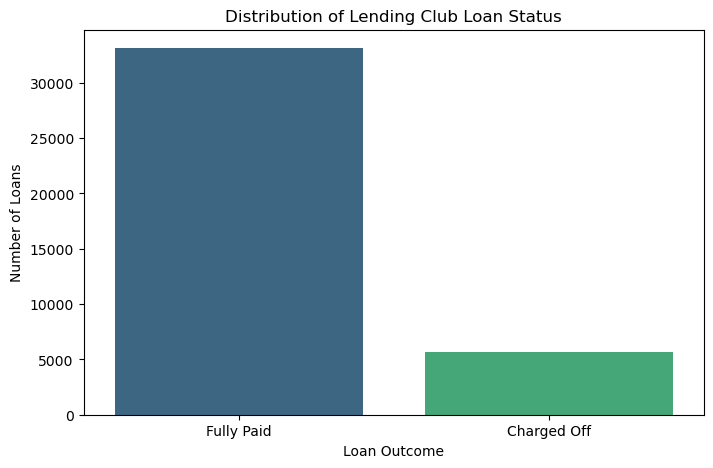

In [8]:
# 3. Create a simple visual bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='loan_status', palette='viridis')
plt.title('Distribution of Lending Club Loan Status')
plt.xlabel('Loan Outcome')
plt.ylabel('Number of Loans')
plt.show()

In risk modeling, understanding the distribution of the target (loan_status) is critical. We must identify if there is a severe class imbalance (e.g., vastly more "Fully Paid" loans than "Charged Off" loans), as this will dictate how we evaluate and train our eventual machine learning model.

## Step 3: Hunt for Missing Data

In [11]:
# Calculate the total number of missing values per column
missing_counts = df.isnull().sum()

# Calculate the percentage of missing values per column
missing_percentages = (df.isnull().mean() * 100).round(2)

# Combine them into a clean DataFrame for easy viewing
missing_data_summary = pd.DataFrame({
    'Total Missing': missing_counts,
    'Percentage (%)': missing_percentages
})

# Filter to show ONLY columns that actually have missing data, sorted highest to lowest
missing_data_summary = missing_data_summary[missing_data_summary['Total Missing'] > 0]
missing_data_summary.sort_values(by='Percentage (%)', ascending=False)

,Total Missing,Percentage (%)
emp_length,1036,2.67
revol_util,50,0.13


In [13]:
# Checking the data types of all columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38770 entries, 0 to 38769
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   38770 non-null  int64  
 1   member_id            38770 non-null  float64
 2   loan_amnt            38770 non-null  float64
 3   term                 38770 non-null  object 
 4   int_rate             38770 non-null  object 
 5   installment          38770 non-null  float64
 6   grade                38770 non-null  object 
 7   sub_grade            38770 non-null  object 
 8   emp_length           37734 non-null  object 
 9   home_ownership       38770 non-null  object 
 10  annual_inc           38770 non-null  float64
 11  verification_status  38770 non-null  object 
 12  purpose              38770 non-null  object 
 13  dti                  38770 non-null  float64
 14  delinq_2yrs          38770 non-null  float64
 15  inq_last_6mths       38770 non-null 

In [14]:
# 2. Get statistical summaries of our numerical columns
# Note: .transpose() flips the table sideways to make it easier to read!
print("\n--- Numerical Statistics ---")
display(df.describe().transpose())


--- Numerical Statistics ---


,count,mean,std,min,25%,50%,75%,max
id,38770.0,676995.973072,209022.602925,54734.00,512703.2500,657993.50,828720.25,1077501.00
member_id,38770.0,843089.188367,264134.540029,70699.00,661910.0000,841092.00,1037009.50,1314167.00
loan_amnt,38770.0,11069.122388,7362.292600,500.00,5325.0000,9737.50,15000.00,35000.00
installment,38770.0,322.629489,208.592815,15.69,165.7400,278.15,426.10,1305.19
annual_inc,38770.0,68800.252230,64161.315787,4000.00,40000.0000,58923.50,82000.00,6000000.00
dti,38770.0,13.276704,6.676355,0.00,8.1300,13.37,18.56,29.99
delinq_2yrs,38770.0,0.146660,0.492197,0.00,0.0000,0.00,0.00,11.00
inq_last_6mths,38770.0,0.871473,1.071444,0.00,0.0000,1.00,1.00,8.00
open_acc,38770.0,9.278850,4.401871,2.00,6.0000,9.00,12.00,44.00
pub_rec,38770.0,0.055404,0.237727,0.00,0.0000,0.00,0.00,4.00


Before feeding data into a machine learning algorithm, we must identify and handle null values. Algorithms cannot process missing data mathematically, requiring us to make engineering decisions on whether to drop rows, drop columns, or impute logical defaults.

## Step 4: Data Preprocessing & Cleaning
**Cleaning Revolving Utilization (revol_util)**
The revolving line utilization rate is a critical percentage, but it is currently stored as a text object due to trailing % signs. Before handling missing values or feeding this into a model, we must strip the string characters and cast the column to a continuous numerical format (float).

In [15]:
# Strip the '%' sign and cast the column to a float
df['revol_util'] = df['revol_util'].str.replace('%', '').astype(float)

# Verify the transformation was successful
print("New data type for revol_util:", df['revol_util'].dtype)
display(df['revol_util'].head())

New data type for revol_util: float64


0    83.7
1     9.4
2    98.5
3    21.0
4    28.3
Name: revol_util, dtype: float64

**Imputing Missing Revolving Utilization**
With only 50 missing values (roughly 0.13% of the dataset), we could safely drop these rows. However, to preserve the surrounding financial data in those rows, we will impute the missing values using the median of the revol_util column. The median is chosen over the mean to prevent extreme outliers from skewing our imputed values.

In [16]:
# Impute missing values with the median
revol_median = df['revol_util'].median()
df['revol_util'] = df['revol_util'].fillna(revol_median)

# Verify no more missing values exist in the column
print("Missing values in revol_util:", df['revol_util'].isnull().sum())

Missing values in revol_util: 0


**Encoding the Target Variable (loan_status)**
Machine learning models require numerical inputs. Our target variable currently contains text categories such as "Fully Paid" and "Charged Off". Because we are building a risk model, our primary objective is to predict defaults. Therefore, we will encode "Charged Off" as the positive minority class (1) and "Fully Paid" as the negative majority class (0).

In [17]:
# Map the target variable to binary integers
status_mapping = {'Fully Paid': 0, 'Charged Off': 1}
df['loan_status'] = df['loan_status'].map(status_mapping)

# Drop any rows that had statuses other than these two (like 'Current' or 'Late')
# Since we only want to train on loans that have fully concluded
df = df.dropna(subset=['loan_status'])
df['loan_status'] = df['loan_status'].astype(int)

# Verify the mapping
print(df['loan_status'].value_counts())

loan_status
0    33136
1     5634
Name: count, dtype: int64
